# Theme 1 — Classical/Static Baseline, Fairness & Calibration

**Owner:** Siam
**Project:** Fairness-Aware, Capacity-Constrained RL for Fraud Alert Triage (FiFAR + BAF)

This notebook is the project's **reference floor** — every other theme (Tanvir's
sequential RL algorithms, Mahdeen's human-AI deferral policy) will be compared
against the numbers produced here, so it's meant to be run first.

Scope (per `Team_Task_Assignment.docx`):
1. Plain LightGBM baseline on `fraud_bool` (excluding the `standard#0..49` synthetic
   expert-prediction columns) — report **Recall @ 5% FPR**.
2. FairGBM (fairness-constrained variant) vs. the plain baseline.
3. Calibration (Platt scaling / isotonic regression) + conformal prediction for
   uncertainty quantification.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

RANDOM_STATE = 42
TARGET_FPR = 0.05


In [2]:
# Works both in Google Colab (matching the team's Phase-0 notebook) and locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Reinforcement_Learning_Research/fifar_prepared'
except ImportError:
    DATA_DIR = 'fifar_prepared'

print("Using DATA_DIR =", DATA_DIR)


Using DATA_DIR = fifar_prepared


## 1. Load the verified, prepared dataset

In [3]:
train = pd.read_parquet(f"{DATA_DIR}/train_months3to5_processed.parquet")
eval_ = pd.read_parquet(f"{DATA_DIR}/eval_months6to7_processed.parquet")
scaler = joblib.load(f"{DATA_DIR}/scaler.joblib")

print("train:", train.shape, "| eval:", eval_.shape)
print("train fraud rate: {:.2%}".format(train["fraud_bool"].mean()))
print("eval fraud rate:  {:.2%}".format(eval_["fraud_bool"].mean()))


train: (20765, 111) | eval: (9857, 111)
train fraud rate: 11.08%
eval fraud rate:  14.33%


## 2. Feature selection

Excluded from the feature set:
- `standard#0` .. `standard#49` — synthetic human-analyst predictions, not real
  model features (Theme 1 is a *classical model* baseline, not a deferral policy).
- `case_id`, `month` — identifiers, not predictive features.
- `device_fraud_count` — verified constant (all zero) in the training data during
  Phase 0 verification, so it carries no signal.
- `fraud_bool` — the label.


In [4]:
drop_cols = {"case_id", "fraud_bool", "month", "device_fraud_count"}
feature_cols = [c for c in train.columns if not c.startswith("standard#") and c not in drop_cols]

print(f"{len(feature_cols)} features selected (from {train.shape[1]} total columns)")

X_train_full, y_train_full = train[feature_cols], train["fraud_bool"]
X_eval, y_eval = eval_[feature_cols], eval_["fraud_bool"]


57 features selected (from 111 total columns)


## 3. Baseline: plain LightGBM

An internal train/validation split (from the *train* months only, stratified on
the label) is used for early stopping. `eval` (months 6-7) is never touched until
final scoring, so it stays a clean temporal holdout.


In [5]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2,
    stratify=y_train_full, random_state=RANDOM_STATE,
)
print("fit:", X_fit.shape, "| val:", X_val.shape, "| eval (untouched holdout):", X_eval.shape)

baseline_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1,
)
baseline_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print("best iteration:", baseline_model.best_iteration_)


fit: (16612, 57) | val: (4153, 57) | eval (untouched holdout): (9857, 57)


best iteration: 26


In [6]:
def recall_at_fpr(y_true, y_score, target_fpr=TARGET_FPR):
    """Recall (TPR) at the largest achievable FPR <= target_fpr."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    idx = max(np.searchsorted(fpr, target_fpr, side="right") - 1, 0)
    return tpr[idx], thresholds[idx], fpr[idx]


p_eval_baseline = baseline_model.predict_proba(X_eval)[:, 1]
baseline_recall, baseline_thr, baseline_actual_fpr = recall_at_fpr(y_eval, p_eval_baseline)
baseline_auc = roc_auc_score(y_eval, p_eval_baseline)

print(f"REFERENCE FLOOR -- Baseline LightGBM")
print(f"  Recall @ {TARGET_FPR:.0%} FPR : {baseline_recall:.4f}")
print(f"  (operating threshold={baseline_thr:.4f}, actual FPR={baseline_actual_fpr:.4f})")
print(f"  ROC-AUC              : {baseline_auc:.4f}")


REFERENCE FLOOR -- Baseline LightGBM
  Recall @ 5% FPR : 0.1946
  (operating threshold=0.1890, actual FPR=0.0500)
  ROC-AUC              : 0.6789


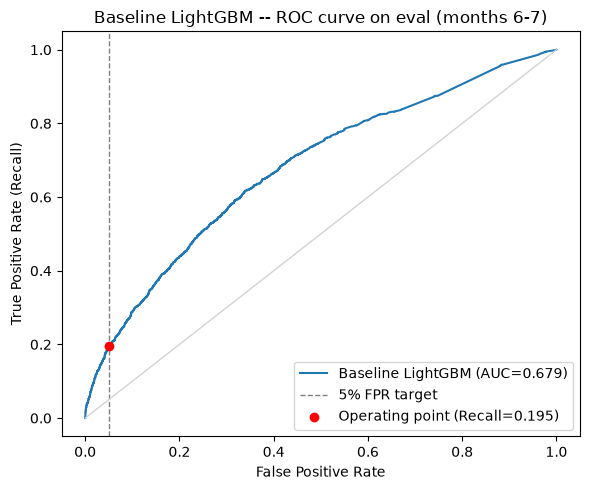

In [7]:
fpr_curve, tpr_curve, _ = roc_curve(y_eval, p_eval_baseline)

plt.figure(figsize=(6, 5))
plt.plot(fpr_curve, tpr_curve, label=f"Baseline LightGBM (AUC={baseline_auc:.3f})")
plt.axvline(TARGET_FPR, color="gray", linestyle="--", linewidth=1, label=f"{TARGET_FPR:.0%} FPR target")
plt.scatter([baseline_actual_fpr], [baseline_recall], color="red", zorder=5,
            label=f"Operating point (Recall={baseline_recall:.3f})")
plt.plot([0, 1], [0, 1], color="lightgray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Baseline LightGBM -- ROC curve on eval (months 6-7)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 4. Fairness diagnostic

BAF-family fairness work treats **age >= 50** as the protected group. Since
`customer_age` was scaled in Phase 0, it's recovered here via the saved scaler's
`mean_`/`scale_` rather than by touching the prepared parquet files.

This shows how unequal the *plain* baseline already is across groups at its
5%-FPR operating threshold -- the gap this section quantifies is exactly what
FairGBM (next section) is meant to shrink.


In [8]:
age_idx = list(scaler.feature_names_in_).index("customer_age")
raw_age_eval = eval_["customer_age"] * scaler.scale_[age_idx] + scaler.mean_[age_idx]
protected_group = (raw_age_eval >= 50).to_numpy()

preds_at_thr = (p_eval_baseline >= baseline_thr).astype(int)
y_eval_arr = y_eval.to_numpy()

fairness_rows = []
for name, mask in [("age < 50", ~protected_group), ("age >= 50 (protected)", protected_group)]:
    yt, yp = y_eval_arr[mask], preds_at_thr[mask]
    neg, pos = (yt == 0).sum(), (yt == 1).sum()
    fp = ((yp == 1) & (yt == 0)).sum()
    tp = ((yp == 1) & (yt == 1)).sum()
    fairness_rows.append({"group": name, "n": mask.sum(), "FPR": fp / neg, "Recall": tp / pos})

fairness_df = pd.DataFrame(fairness_rows)
print(fairness_df.to_string(index=False))
print(f"\nFPR gap (predictive-equality violation): {abs(fairness_df['FPR'].diff().iloc[-1]):.4f}")


                group    n      FPR   Recall
             age < 50 6053 0.040320 0.157233
age >= 50 (protected) 3804 0.065913 0.242718

FPR gap (predictive-equality violation): 0.0256


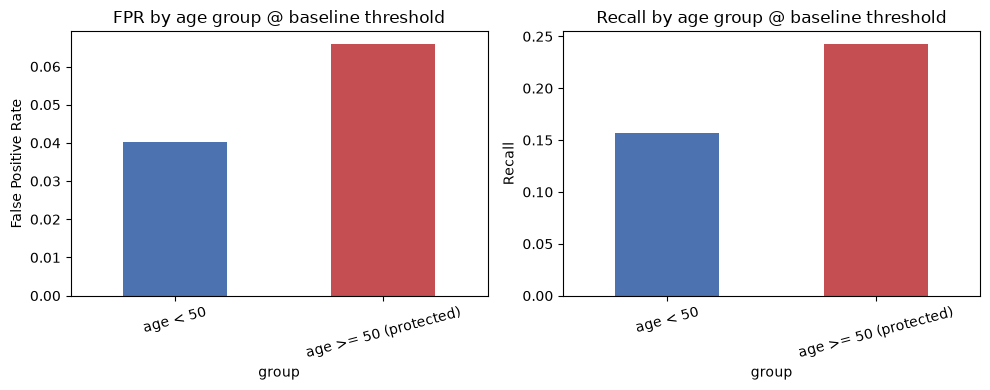

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fairness_df.plot.bar(x="group", y="FPR", ax=ax[0], legend=False, color=["#4C72B0", "#C44E52"])
ax[0].set_title("FPR by age group @ baseline threshold")
ax[0].set_ylabel("False Positive Rate")
ax[0].tick_params(axis="x", rotation=15)

fairness_df.plot.bar(x="group", y="Recall", ax=ax[1], legend=False, color=["#4C72B0", "#C44E52"])
ax[1].set_title("Recall by age group @ baseline threshold")
ax[1].set_ylabel("Recall")
ax[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## 5. FairGBM (fairness-constrained variant)

**Environment note:** the `fairgbm` PyPI package ships prebuilt native
libraries for Linux/Mac only -- there is no official Windows wheel, so this
cell will not train locally on Windows. It **will** work in Google Colab
(Linux), consistent with how Phase 0 of this project was run. The training
code below is complete and ready to run there; on Windows it prints a clear
skip message instead of crashing the notebook.

**If the FPR gap comes out *larger* than the baseline's after re-running with
early stopping fixed:** the next suspect is that the `FPR` constraint is
enforced at FairGBM's own internal decision threshold during training, not at
the re-calibrated threshold `recall_at_fpr` picks afterward to hit 5% overall
FPR. Equalizing FPR at one threshold doesn't guarantee it stays equalized at a
different one. Worth checking FairGBM's `constraint_fpr_tolerance` parameter
and comparing group FPRs at FairGBM's own default threshold (0.5) rather than
the recalibrated one, to isolate whether that's what's happening.


In [10]:
try:
    from fairgbm import FairGBMClassifier
    FAIRGBM_AVAILABLE = True
except Exception as e:
    FAIRGBM_AVAILABLE = False
    print(f"FairGBM not available in this environment ({type(e).__name__}).")
    print("Run this cell in Google Colab or WSL/Linux to train FairGBM -- ")
    print("no prebuilt wheel exists for native Windows Python.")


FairGBM not available in this environment (Exception).
Run this cell in Google Colab or WSL/Linux to train FairGBM -- 
no prebuilt wheel exists for native Windows Python.


In [11]:
if FAIRGBM_AVAILABLE:
    constraint_group_fit = (
        X_fit["customer_age"] * scaler.scale_[age_idx] + scaler.mean_[age_idx] >= 50
    ).astype(int).to_numpy()

    # Capped to the baseline's own early-stopped tree count (n_estimators=
    # baseline_model.best_iteration_) instead of using eval_set-based early
    # stopping here: FairGBM's sklearn API wants eval_set's constraint_group
    # supplied via a separate per-eval-set argument, and passing a plain
    # array (as if it were the same shape as constraint_group) raised
    # `TypeError: constraint_group should be dict or list` -- rather than
    # guess an unverified kwarg name (no Linux fairgbm here to test against),
    # matching tree count directly achieves the same goal: the first run of
    # this cell trained FairGBM for the full 1000 rounds with no cap at all,
    # while the baseline stopped at 26 trees via early stopping, which
    # overfit FairGBM and invalidated the comparison (both recall AND the
    # fairness gap looked worse purely as a result of that mismatch).
    fairgbm_model = FairGBMClassifier(
        n_estimators=baseline_model.best_iteration_,
        learning_rate=0.03,
        num_leaves=31,
        random_state=RANDOM_STATE,
        constraint_type="FPR",  # equalize false-positive rate across the protected group
    )
    fairgbm_model.fit(X_fit, y_fit, constraint_group=constraint_group_fit)
    print(f"baseline trees: {baseline_model.best_iteration_}  |  FairGBM trees: {fairgbm_model.n_estimators}")

    p_eval_fair = fairgbm_model.predict_proba(X_eval)[:, 1]
    fair_recall, fair_thr, fair_actual_fpr = recall_at_fpr(y_eval, p_eval_fair)

    preds_fair_at_thr = (p_eval_fair >= fair_thr).astype(int)
    fair_rows = []
    for name, mask in [("age < 50", ~protected_group), ("age >= 50 (protected)", protected_group)]:
        yt, yp = y_eval_arr[mask], preds_fair_at_thr[mask]
        neg, pos = (yt == 0).sum(), (yt == 1).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        tp = ((yp == 1) & (yt == 1)).sum()
        fair_rows.append({"group": name, "n": mask.sum(), "FPR": fp / neg, "Recall": tp / pos})
    fair_fairness_df = pd.DataFrame(fair_rows)

    print(f"FairGBM Recall @ {TARGET_FPR:.0%} FPR: {fair_recall:.4f}  (baseline was {baseline_recall:.4f})")
    print(f"FairGBM FPR gap: {abs(fair_fairness_df['FPR'].diff().iloc[-1]):.4f}  "
          f"(baseline was {abs(fairness_df['FPR'].diff().iloc[-1]):.4f})")
    print()
    print(fair_fairness_df.to_string(index=False))
else:
    fair_recall = None
    print("Skipped -- see environment note above. Baseline fairness numbers from Section 4 stand until this is run in Colab.")


Skipped -- see environment note above. Baseline fairness numbers from Section 4 stand until this is run in Colab.


## 6. Calibration: Platt scaling & isotonic regression

Both calibrators are fit on the held-out `X_val`/`y_val` split (never on `eval`),
then compared on `eval` via Brier score (lower is better) and a reliability
diagram.


In [12]:
try:
    from sklearn.frozen import FrozenEstimator
    def make_calibrated(model, method):
        return CalibratedClassifierCV(FrozenEstimator(model), method=method).fit(X_val, y_val)
except ImportError:  # older scikit-learn
    def make_calibrated(model, method):
        return CalibratedClassifierCV(model, method=method, cv="prefit").fit(X_val, y_val)

platt_model = make_calibrated(baseline_model, "sigmoid")
isotonic_model = make_calibrated(baseline_model, "isotonic")

p_raw = baseline_model.predict_proba(X_eval)[:, 1]
p_platt = platt_model.predict_proba(X_eval)[:, 1]
p_isotonic = isotonic_model.predict_proba(X_eval)[:, 1]

calibration_df = pd.DataFrame({
    "method": ["raw (uncalibrated)", "Platt scaling", "isotonic regression"],
    "brier_score": [
        brier_score_loss(y_eval, p_raw),
        brier_score_loss(y_eval, p_platt),
        brier_score_loss(y_eval, p_isotonic),
    ],
})
print(calibration_df.to_string(index=False))


             method  brier_score
 raw (uncalibrated)     0.116903
      Platt scaling     0.115531
isotonic regression     0.115659


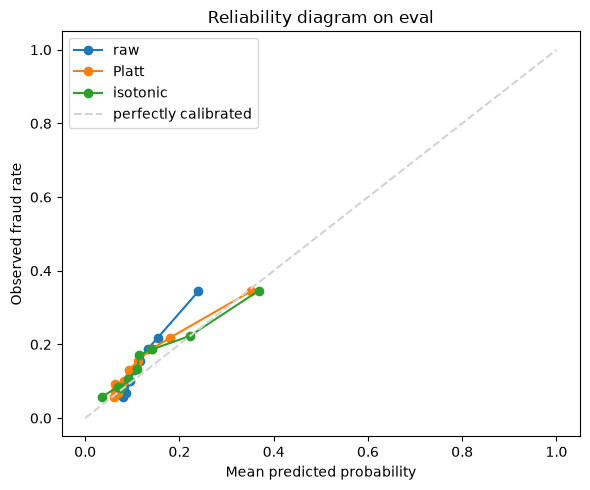

In [13]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(6, 5))
for label, probs in [("raw", p_raw), ("Platt", p_platt), ("isotonic", p_isotonic)]:
    frac_pos, mean_pred = calibration_curve(y_eval, probs, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
plt.plot([0, 1], [0, 1], color="lightgray", linestyle="--", label="perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraud rate")
plt.title("Reliability diagram on eval")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Conformal prediction (uncertainty quantification)

Split conformal prediction using the calibrated (Platt) probabilities: nonconformity
scores are computed on `X_val`/`y_val`, and a coverage-`1-alpha` quantile is used to
build prediction sets on `eval`. A prediction set of size 1 is a confident call,
size 2 (`{not-fraud, fraud}`) flags genuine model uncertainty.


In [14]:
ALPHA = 0.10  # target 90% coverage

p_val_platt = platt_model.predict_proba(X_val)[:, 1]
nonconformity = np.where(y_val.to_numpy() == 1, 1 - p_val_platt, p_val_platt)

n = len(nonconformity)
q_level = np.ceil((n + 1) * (1 - ALPHA)) / n
qhat = np.quantile(nonconformity, q_level, method="higher")

in_set_notfraud = p_platt <= qhat        # nonconformity of "not fraud" label is p(fraud)
in_set_fraud = (1 - p_platt) <= qhat     # nonconformity of "fraud" label is 1 - p(fraud)
set_size = in_set_notfraud.astype(int) + in_set_fraud.astype(int)
true_in_set = np.where(y_eval.to_numpy() == 1, in_set_fraud, in_set_notfraud)

print(f"target coverage: {1 - ALPHA:.0%}")
print(f"empirical coverage on eval: {true_in_set.mean():.4f}")
print(f"average prediction-set size: {set_size.mean():.4f}")
print(f"  singleton (confident) predictions: {(set_size == 1).mean():.2%}")
print(f"  ambiguous ({{fraud, not-fraud}}) predictions: {(set_size == 2).mean():.2%}")


target coverage: 90%
empirical coverage on eval: 0.8748
average prediction-set size: 1.0397
  singleton (confident) predictions: 96.03%
  ambiguous ({fraud, not-fraud}) predictions: 3.97%


## 8. Summary — reference floor for the project

In [15]:
summary_rows = [
    {"metric": f"Recall @ {TARGET_FPR:.0%} FPR (plain LightGBM)", "value": f"{baseline_recall:.4f}"},
    {"metric": "ROC-AUC (plain LightGBM)", "value": f"{baseline_auc:.4f}"},
    {"metric": "FPR gap, age<50 vs age>=50 (plain LightGBM)", "value": f"{abs(fairness_df['FPR'].diff().iloc[-1]):.4f}"},
    {"metric": f"Recall @ {TARGET_FPR:.0%} FPR (FairGBM)", "value": f"{fair_recall:.4f}" if fair_recall is not None else "not run on this machine -- run in Colab"},
    {"metric": "Brier score, raw vs Platt vs isotonic", "value": ", ".join(f"{v:.4f}" for v in calibration_df['brier_score'])},
    {"metric": "Conformal empirical coverage (target 90%)", "value": f"{true_in_set.mean():.4f}"},
    {"metric": "Conformal average set size", "value": f"{set_size.mean():.4f}"},
]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


                                     metric                                   value
           Recall @ 5% FPR (plain LightGBM)                                  0.1946
                   ROC-AUC (plain LightGBM)                                  0.6789
FPR gap, age<50 vs age>=50 (plain LightGBM)                                  0.0256
                  Recall @ 5% FPR (FairGBM) not run on this machine -- run in Colab
      Brier score, raw vs Platt vs isotonic                  0.1169, 0.1155, 0.1157
  Conformal empirical coverage (target 90%)                                  0.8748
                 Conformal average set size                                  1.0397
